In [1]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#Dataset
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


## 4. Explorar el dataset

Observemos la estructura del `DataFrame`.

In [4]:
print("Dimensiones (filas, columnas):", df.shape)
print()
print("Columnas:")
for columna in df.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (39562, 7)

Columnas:
  - entity
  - code
  - year
  - deaths__sex_all__age_all__variant_estimates
  - deaths__sex_all__age_all__variant_medium__projected
  - births__sex_all__age_all__variant_estimates
  - births__sex_all__age_all__variant_medium__projected


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39562 entries, 0 to 39561
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   entity                                               39562 non-null  str    
 1   code                                                 38354 non-null  str    
 2   year                                                 39562 non-null  int64  
 3   deaths__sex_all__age_all__variant_estimates          18944 non-null  float64
 4   deaths__sex_all__age_all__variant_medium__projected  19712 non-null  float64
 5   births__sex_all__age_all__variant_estimates          19166 non-null  float64
 6   births__sex_all__age_all__variant_medium__projected  19943 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 2.1 MB


In [7]:
print("Número de entidades:", df["entity"].nunique())
df["entity"].unique()

Número de entidades: 262


<StringArray>
[      'Afghanistan',            'Africa',       'Africa (UN)',
           'Albania',           'Algeria',    'American Samoa',
     'Americas (UN)',           'Andorra',            'Angola',
          'Anguilla',
 ...
           'Vanuatu',           'Vatican',         'Venezuela',
           'Vietnam', 'Wallis and Futuna',    'Western Sahara',
             'World',             'Yemen',            'Zambia',
          'Zimbabwe']
Length: 262, dtype: str

In [3]:
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})


df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [4]:
df_inicial = df.copy()
df_inicial.head(3)

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN


In [5]:
# Columna unificada: dato histórico si existe; si no, la proyección de OWID
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])
df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


In [6]:
pais = "China"

df_china = df[df["Entity"] == pais]

df_china.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN,22293376.0,12564023.0
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN,22144814.0,12411701.0
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN,25496318.0,12459848.0
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN,24139416.0,12309525.0
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN,25438544.0,12145578.0


In [7]:
print("Rango de años:", df_china["Year"].min(), "-", df_china["Year"].max())
print("Número de filas:", df_china.shape[0])

Rango de años: 1950 - 2100
Número de filas: 151


## 7. Revisar las variables disponibles

Identifica las columnas correspondientes a: **año**, **nacimientos** y **defunciones**.

In [14]:
df_china.columns

Index(['Entity', 'Code', 'Year', 'deaths_estimates', 'deaths_projected',
       'births_estimates', 'births_projected', 'births', 'deaths'],
      dtype='str')

# PARTE 4. Explorar visualmente los datos

## 8. Nacimientos a través del tiempo

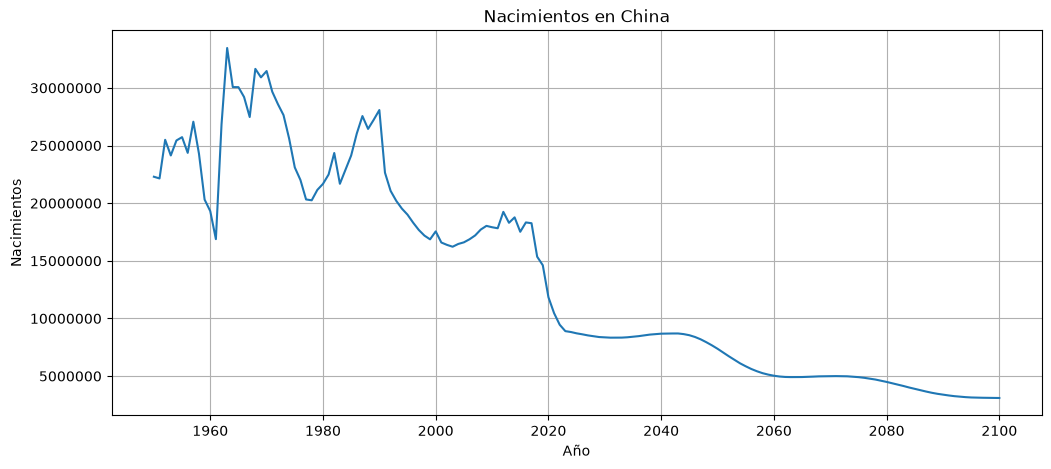

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_china["Year"],
    df_china["births"]
)

plt.title("Nacimientos en China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

## 9. Defunciones a través del tiempo

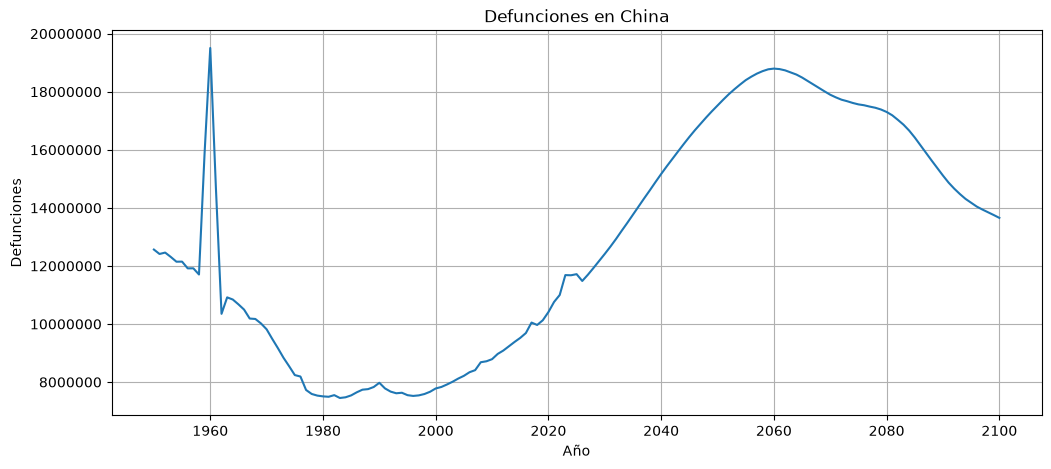

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_china["Year"],
    df_china["deaths"]
)

plt.title("Defunciones en China")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

### Comparacion con mexico

China muestra un resultado más variado,hubo años donde hubo un pico, y se mantuvo en decadencia y despues empezo a subir lentamente.
Y las predicciones indican que puede que baje en un futuro.



In [9]:
ultimo_historico = df_china.loc[df_china["births_estimates"].notna(), "Year"].max()
primera_proyeccion = df_china.loc[df_china["births_projected"].notna(), "Year"].min()

print("Último año con dato histórico:", ultimo_historico)
print("Primer año con proyección de OWID:", primera_proyeccion)

Último año con dato histórico: 2023
Primer año con proyección de OWID: 2024


Para esta práctica utilizaremos como punto de separación el **año 2023**. Creamos dos `DataFrames`:

In [13]:
df_historico = df_china[
    df_china["Year"] <= 2023
]

df_proyectado = df_china[
    df_china["Year"] > 2023
]

In [14]:
print("Histórico  ->", df_historico.shape, "| años:", df_historico["Year"].min(), "a", df_historico["Year"].max())
print("Proyectado ->", df_proyectado.shape, "| años:", df_proyectado["Year"].min(), "a", df_proyectado["Year"].max())

Histórico  -> (74, 9) | años: 1950 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


Comprobemos que no haya valores faltantes en las variables que vamos a utilizar para entrenar:

In [15]:
df_historico[["Year", "births", "deaths"]].isna().sum()

Year      0
births    0
deaths    0
dtype: int64

In [16]:
X = df_historico[["Year"]]
y_nacimientos = df_historico["births"]

In [17]:
X.head()

,Year
7097,1950
7098,1951
7099,1952
7100,1953
7101,1954


In [18]:
y_nacimientos.head()

7097    22293376.0
7098    22144814.0
7099    25496318.0
7100    24139416.0
7101    25438544.0
Name: births, dtype: float64

## 12. Convertir los datos a NumPy

Obtenemos los valores como arreglos de NumPy:

In [19]:
X_numpy = X.to_numpy()
y_numpy = y_nacimientos.to_numpy()

print("X_numpy.shape:", X_numpy.shape)
print("y_numpy.shape:", y_numpy.shape)

X_numpy.shape: (74, 1)
y_numpy.shape: (74,)


In [20]:
type(X_numpy), type(y_numpy)

(numpy.ndarray, numpy.ndarray)

In [ ]:
# Crear y entrenar modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y_nacimientos)


Pendiente (a): -187208.31004813028
Intercepto (b): 393489519.9376378


In [27]:
print("Pendiente (a):", modelo_lineal.coef_[0])
print("Intercepto (b):", modelo_lineal.intercept_)

Pendiente (a): -187208.31004813028
Intercepto (b): 393489519.9376378


In [ ]:
#Predicciones
predicciones_lineal = modelo_lineal.predict(X)
predicciones_lineal[:10]

array([28433315.34378374, 28246107.03373563, 28058898.72368747,
       27871690.41363937, 27684482.10359126, 27497273.7935431 ,
       27310065.483495  , 27122857.17344683, 26935648.86339873,
       26748440.55335057])

In [29]:
anios_futuros = np.arange(2000, 2101).reshape(-1, 1)

print("Forma:", anios_futuros.shape)
anios_futuros[:10]

Forma: (101, 1)


array([[2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009]])

In [30]:
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro.head()

,Year
0,2000
1,2001
2,2002
3,2003
4,2004


In [32]:
predicciones_lineal_futuras = modelo_lineal.predict(X_futuro)
print(predicciones_lineal_futuras[:10])

[19072899.84137726 18885691.5313291  18698483.22128099 18511274.91123283
 18324066.60118473 18136858.29113656 17949649.98108846 17762441.67104036
 17575233.36099219 17388025.05094409]


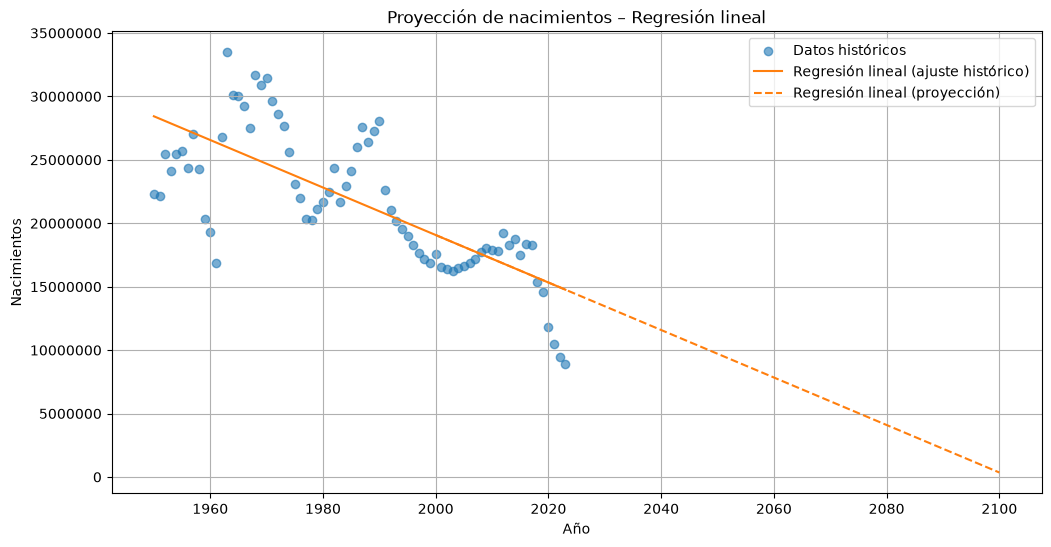

In [33]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

# Ajuste del modelo sobre los años históricos
plt.plot(
    df_historico["Year"],
    predicciones_lineal,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

# Proyección hacia el futuro
plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("Proyección de nacimientos – Regresión lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación
Cambia con respecto a méxico, esta muestra una pendiente negativa por las tendencias de los datos que van en decadencia.

In [35]:
# Regrecion polinomial
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

Transformamos `X`:

In [36]:
X_poly = poly.fit_transform(X)
X_poly[:5]

array([[1.950000e+03, 3.802500e+06],
       [1.951000e+03, 3.806401e+06],
       [1.952000e+03, 3.810304e+06],
       [1.953000e+03, 3.814209e+06],
       [1.954000e+03, 3.818116e+06]])

In [37]:
modelo_polinomial = LinearRegression()

modelo_polinomial.fit(
    X_poly,
    y_nacimientos
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[15379568.11, -3918.14]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.507e+10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[730030.32, 0.88]"


In [38]:
predicciones_polinomiales = modelo_polinomial.predict(
    X_poly
)

In [39]:
anios_futuros_poly = poly.transform(
    X_futuro
)

predicciones_polinomiales_futuras = modelo_polinomial.predict(
    anios_futuros_poly
)

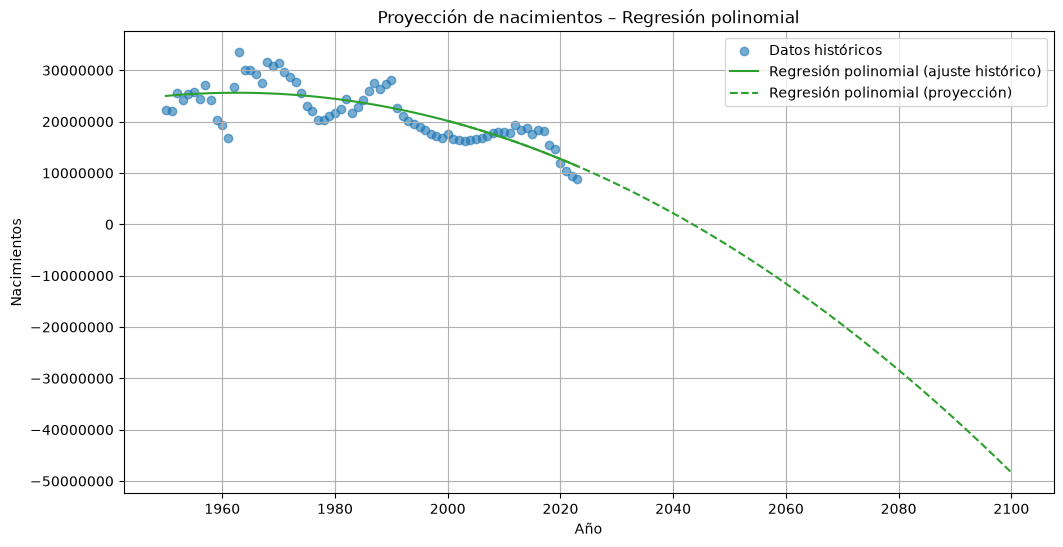

In [40]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_polinomiales,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("Proyección de nacimientos – Regresión polinomial")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Pese que igual el modelado no es tan preciso, mantiene la tendencia de la pendiente negativa, predice menos nacimientos.



In [42]:
#Random forest
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

## 24. Entrenar el modelo

In [43]:
modelo_rf.fit(
    X,
    y_nacimientos
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [45]:
predicciones_rf = modelo_rf.predict(X)
predicciones_rf_futuras = modelo_rf.predict(
    X_futuro
)

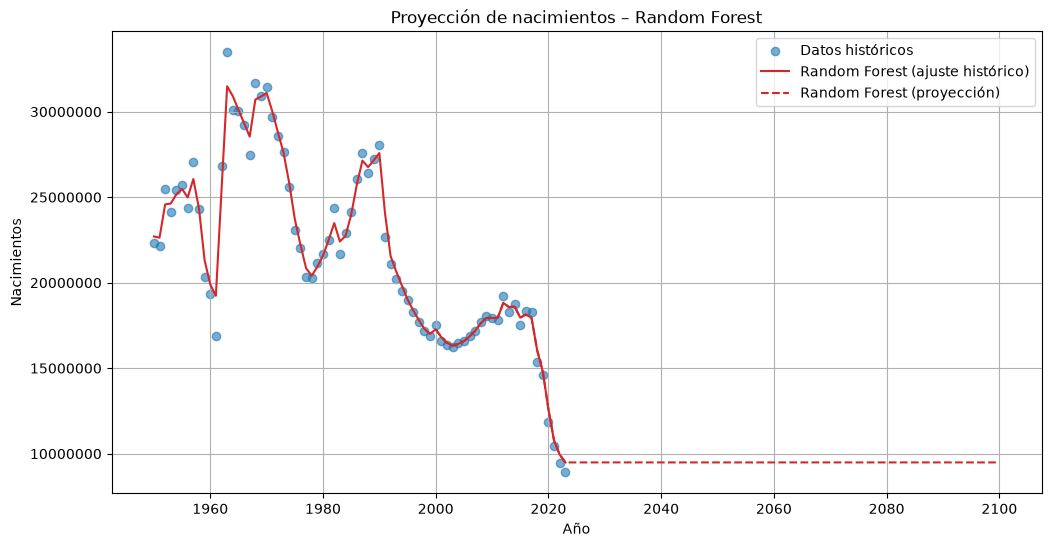

In [46]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_rf,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("Proyección de nacimientos – Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Este pudo modelar más preciso el modelo, aunque la predicción es mala, se queda con lo que conoce y no cambia o predice a futuro.

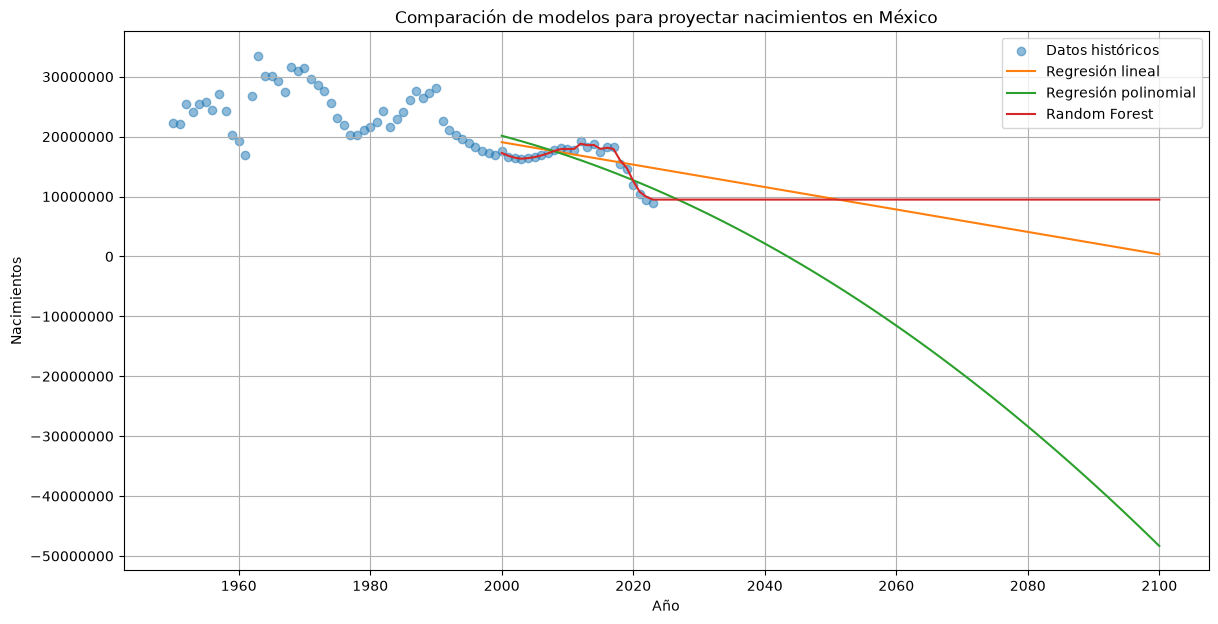

In [47]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar nacimientos en México"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

In [48]:
y_defunciones = df_historico["deaths"]

## 30. Regresión lineal para defunciones

In [49]:
modelo_lineal_deaths = LinearRegression()

modelo_lineal_deaths.fit(
    X,
    y_defunciones
)

predicciones_lineal_deaths = modelo_lineal_deaths.predict(
    X_futuro
)

In [50]:
modelo_polinomial_deaths = LinearRegression()

modelo_polinomial_deaths.fit(
    X_poly,
    y_defunciones
)

predicciones_polinomiales_deaths = modelo_polinomial_deaths.predict(
    anios_futuros_poly
)

In [51]:
modelo_rf_deaths = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_deaths.fit(
    X,
    y_defunciones
)

predicciones_rf_deaths = modelo_rf_deaths.predict(
    X_futuro
)

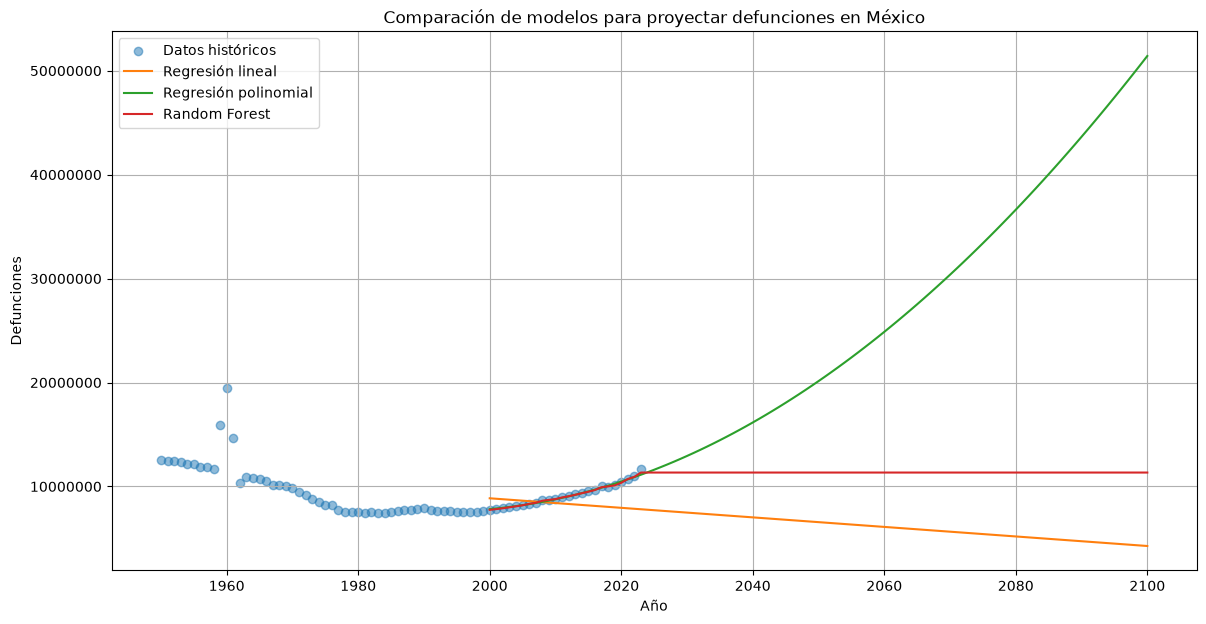

In [52]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_deaths,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_deaths,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_deaths,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar defunciones en México"
)

plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

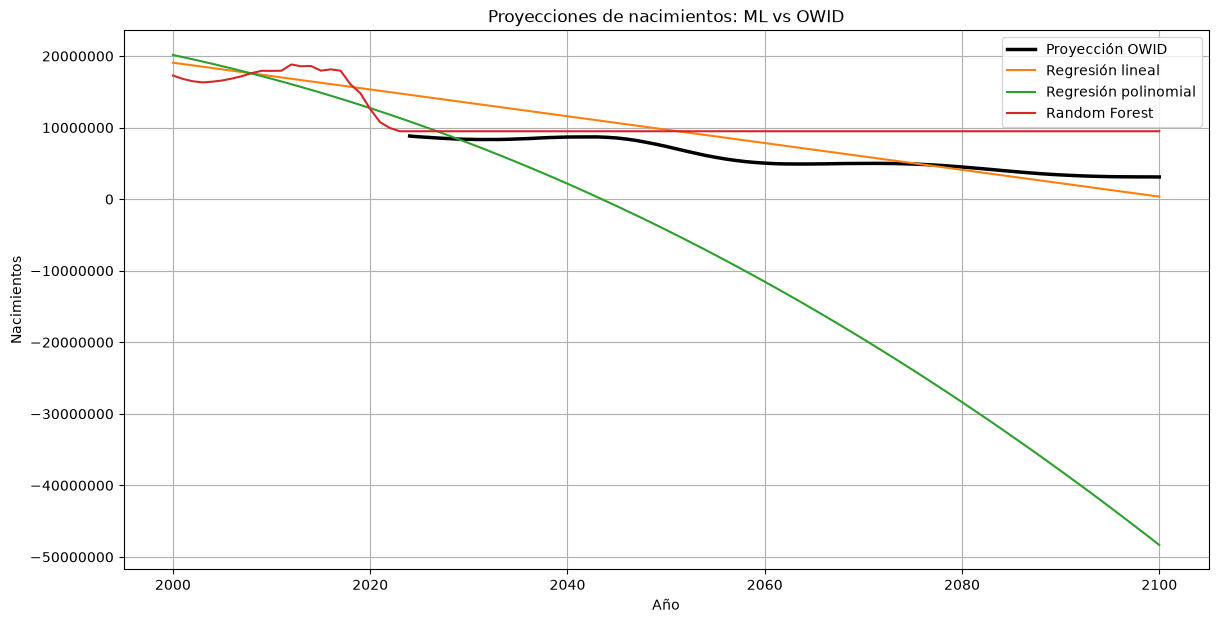

In [53]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado["Year"],
    df_proyectado["births"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Proyecciones de nacimientos: ML vs OWID"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

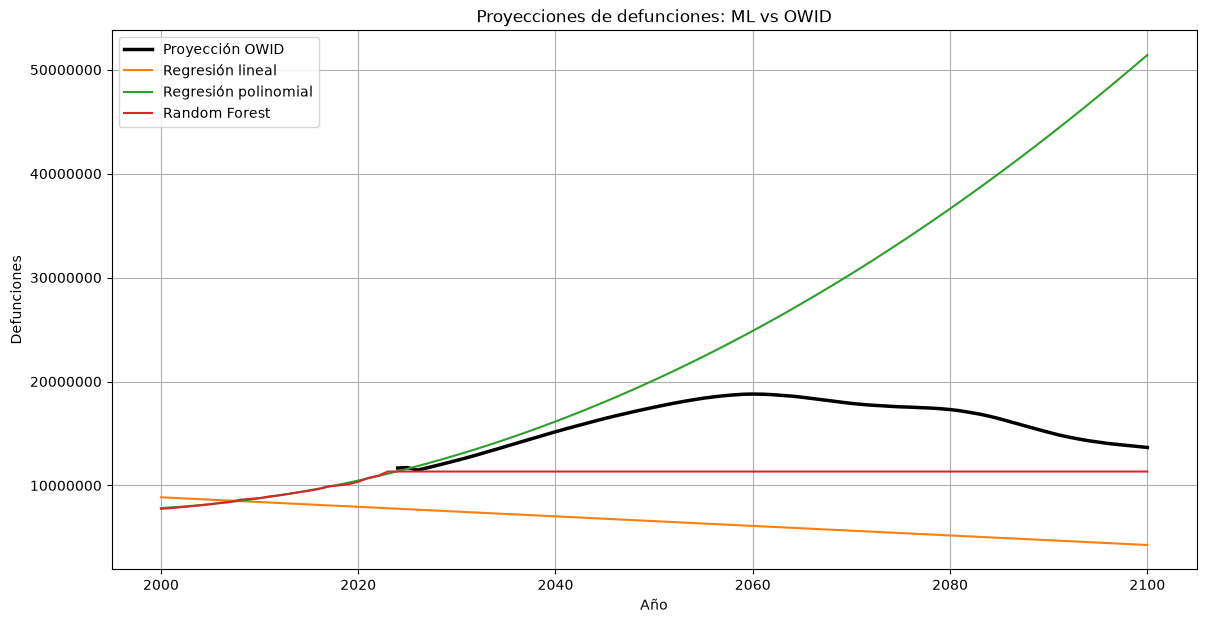

In [54]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado["Year"],
    df_proyectado["deaths"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_deaths,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_deaths,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_deaths,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Proyecciones de defunciones: ML vs OWID"
)

plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()